In [54]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import generate_areas as ga
from image_anal_class import Fringe
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
img_path = 'drop-211025-2/drop-0100.jpg'

Select = ga.SelectLine(img_path, 'my_window')
line = Select.select_line_from_img()

1: [(172, 348)]
2: [(172, 348), (227, 347)]


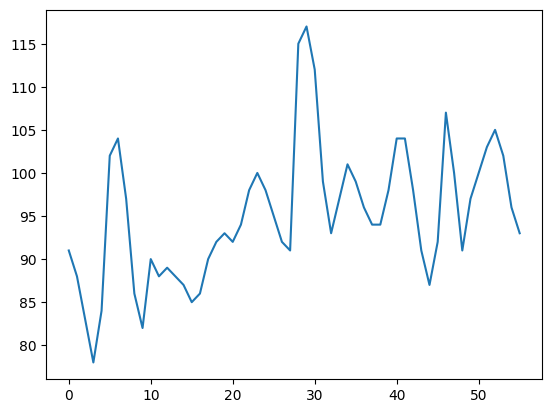

In [15]:
plt.figure()
plt.plot(line)
plt.show()

In [16]:
print(len(line))
dist = np.arange(len(line))

56


# Approximate the indtencity distribution by a function $$ a1+a2*x+a3*x^2 + b1*cos(c1+c2*x) $$
# using scipy function "curve_fit" for determination of coefficients


# Koeffitient "c2" is the frequency of the signal we need to find.

In [17]:
from scipy.optimize import curve_fit

In [47]:
def func(x, a1,a2,a3,b1,c1,c2):
    return a1+a2*x+a3*x**2 + b1*np.cos(c1+c2*x)

In [48]:
popt, pcov = curve_fit(func, dist, line)
print(popt)

[ 8.48506958e+01  6.46410846e-01 -7.35757568e-03  6.19203843e+00
 -1.47434716e-01  1.09015736e+00]


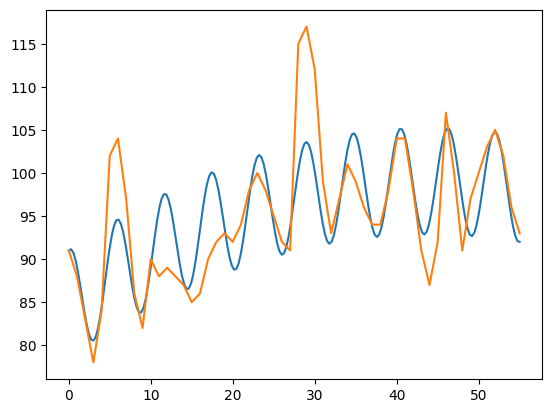

In [49]:
dist_fit = np.linspace(0,55,200)
line_fit = func(dist_fit, *popt)

plt.figure()
plt.plot(dist_fit, line_fit, dist, line)
plt.show()

## Now let's find the frequency of the signal by using phase unwrapping with pre-filtration


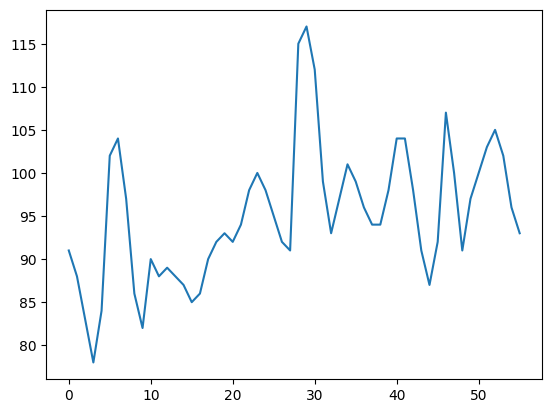

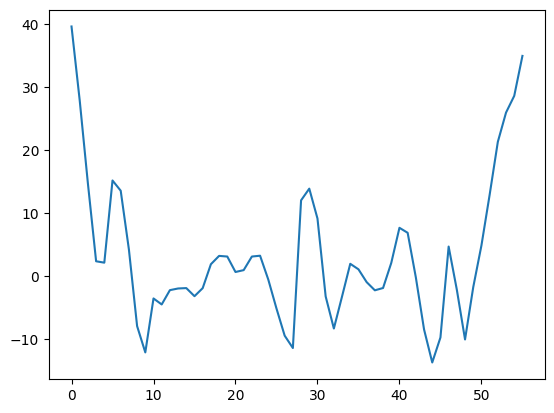

8


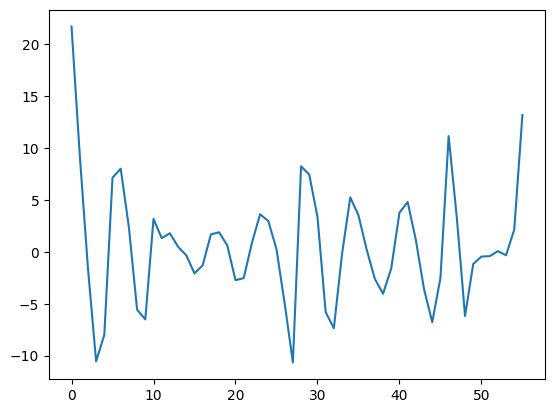

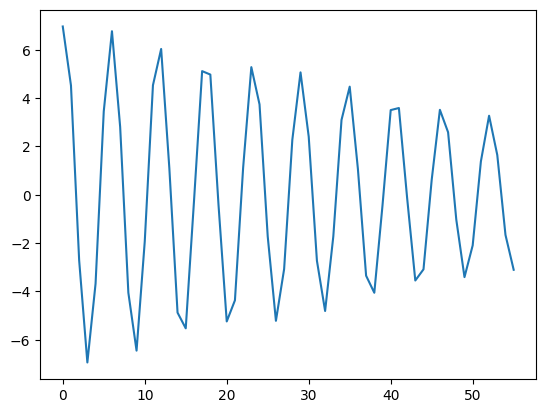

1.0897607487744378


In [67]:
fringe = Fringe(signal = line, fs = 1)
fringe.plot()
fringe.filter_low_frq(nl=3)
fringe.plot()
peak_count = fringe.count_peaks_of_autocorr()
print(peak_count)
fringe.filter_low_frq(nl=peak_count)
fringe.plot()
fringe.update_Wn(rel_h=0.5)
fringe.filter_notch_Wn()
fringe.plot()
frq = fringe.get_frq()
print(frq)